Total (user, bucket) observations: 794389
Buckets present: 168
Bucket   0 | n_users= 1224 | best_k=7 | sil=0.3699
shape: (7, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u64   │
╞═════════╪═══════╡
│ 0       ┆ 192   │
│ 1       ┆ 277   │
│ 2       ┆ 366   │
│ 3       ┆ 164   │
│ 4       ┆ 43    │
│ 5       ┆ 55    │
│ 6       ┆ 127   │
└─────────┴───────┘

Bucket   1 | n_users= 1227 | best_k=7 | sil=0.3787
shape: (7, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u64   │
╞═════════╪═══════╡
│ 0       ┆ 47    │
│ 1       ┆ 354   │
│ 2       ┆ 73    │
│ 3       ┆ 284   │
│ 4       ┆ 167   │
│ 5       ┆ 145   │
│ 6       ┆ 157   │
└─────────┴───────┘

Bucket   2 | n_users= 1254 | best_k=7 | sil=0.3892
shape: (7, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u64   │
╞═════════╪═══════╡
│ 0       ┆ 66    │
│ 1       ┆ 131   │
│ 2       ┆ 354   │
│ 3       ┆ 314   │
│ 4       ┆ 42    │
│ 5       ┆ 187   │


ModuleNotFoundError: No module named 'pyarrow'

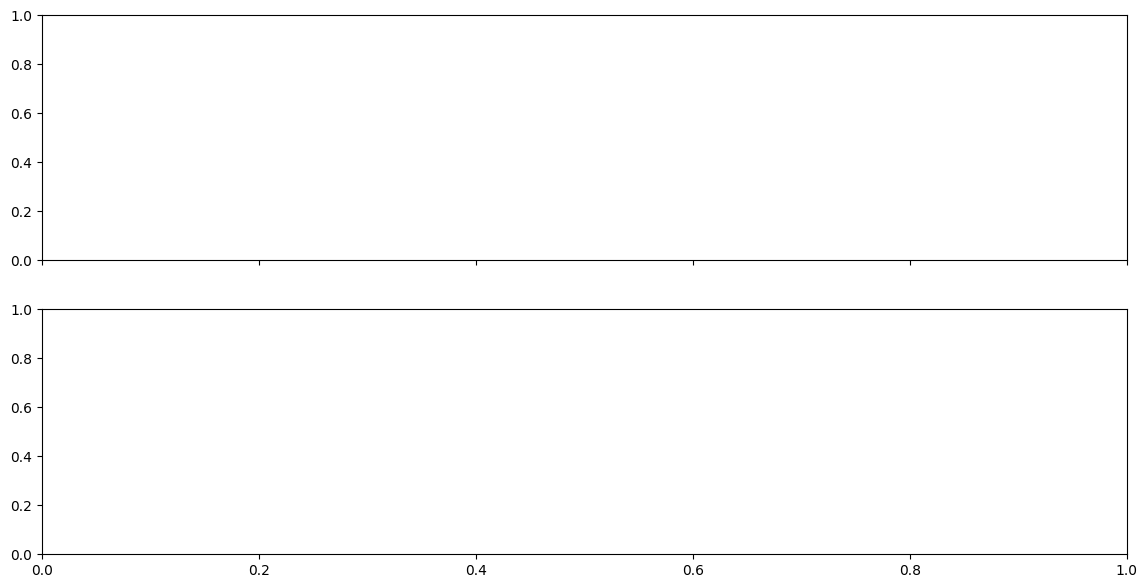

In [1]:
# %% [markdown]
# # Hourly Clustering Run
#
# Aggregation level = 1 hour, window size = 1 hour.
# Each partition is one feature vector per (user, bucket) for a single hour.
# We run 168 windows (7 days × 24 hours) and track optimal k and silhouette per window.

# %% [markdown]
# ## Data & Packages

# %%
# Main packages
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Parallel processing packages
from joblib import Parallel, delayed

# %%
# Load data
df = pl.scan_csv(
    "/home/lanl/data/cyber1/auth.txt.gz",
    has_header=False,
    separator=",",
    new_columns=[
        "time", "src_user", "dest_user", "src_comp", "dest_comp",
        "auth_type", "logon_type", "auth_orientation", "outcome",
    ],
)

# %%
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

# %% [markdown]
# ## Functions & Global Info

# %%
# Time conversions
SECONDS_IN_DAY = 60 * 60 * 24

# Aggregation level (hours)
agg_hour_level = 1
AGG_SECONDS = agg_hour_level * 60 * 60

# Number of windows in 7 days at 1hr aggregation
N_WINDOWS = 7 * 24  # 168

# %%
# FUNCTION - build features dataframe
def build_features(df, agg_hour_level):
    AGG_SECONDS = agg_hour_level * 60 * 60
    return (
        df.with_columns(
            bucket=pl.col("time") // AGG_SECONDS,
            theta=((pl.col("time") % SECONDS_IN_DAY) / SECONDS_IN_DAY) * 2 * np.pi,
            is_failure=(pl.col("outcome") == "Fail").cast(pl.Int8),
        )
        .group_by(["src_user", "bucket"])
        .agg(
            n_events=pl.len(),
            failure_ratio=pl.col("is_failure").mean(),
            n_distinct_dest=pl.col("dest_comp").n_unique(),
            n_distinct_src=pl.col("src_comp").n_unique(),
            c_bar=pl.col("theta").cos().mean(),
            s_bar=pl.col("theta").sin().mean(),
        )
        .with_columns(
            log_n_events=pl.col("n_events").log1p(),
            log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
            log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

# %%
# Relevant feature columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

# %%
# FUNCTION - extract and scale a single bucket (one hourly window)
def cluster_preprocess_bucket(features_df, feature_cols, bucket_id):
    features_bucket = features_df.filter(pl.col("bucket") == bucket_id)
    X = features_bucket.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return features_bucket, X_scaled

# %%
# FUNCTION - fit kmeans for a single k
def fit_kmeans(k, Y, sample_size):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    sil = silhouette_score(Y, labels, sample_size=sample_size, random_state=123)
    ch  = calinski_harabasz_score(Y, labels)
    db  = davies_bouldin_score(Y, labels)
    return k, sil, ch, db

# %% [markdown]
# ## Build Features

# %%
features_df = build_features(df, agg_hour_level)

# Restrict to first 7 days worth of buckets (buckets 0 to 167)
features_df = features_df.filter(pl.col("bucket") < N_WINDOWS)

print(f"Total (user, bucket) observations: {len(features_df)}")
print(f"Buckets present: {features_df['bucket'].n_unique()}")

# %% [markdown]
# ## Loop Over All 168 Hourly Windows

# %%
sample_size = 100_000
k_range = range(2, 11)

# Store summary results across windows
window_results = []

for bucket_id in range(N_WINDOWS):

    features_bucket, X_scaled = cluster_preprocess_bucket(features_df, feature_cols, bucket_id)

    n_users = len(features_bucket)

    # Skip windows with too few users to cluster meaningfully
    if n_users < 10:
        print(f"Bucket {bucket_id:>3d} | skipped (only {n_users} users)")
        window_results.append({
            "bucket": bucket_id,
            "n_users": n_users,
            "best_k": None,
            "best_sil": None,
            "skipped": True,
        })
        continue

    # Cap k_range to avoid k >= n_users
    valid_k_range = [k for k in k_range if k < n_users]

    # Fit kmeans in parallel across k values
    results = Parallel(n_jobs=-1)(
        delayed(fit_kmeans)(k, X_scaled, sample_size) for k in valid_k_range
    )

    # Select best k by silhouette
    best_result = max(results, key=lambda row: row[1])
    best_k, best_sil, best_ch, best_db = best_result

    # Refit on best k
    km = KMeans(n_clusters=best_k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled)

    # Attach labels back
    features_bucket = (
        features_bucket
        .with_columns(pl.Series("cluster", labels))
        .select(["src_user", "bucket", "cluster"])
    )

    # Cluster breakdown
    cluster_counts = features_bucket["cluster"].value_counts().sort("cluster")

    print(
        f"Bucket {bucket_id:>3d} | n_users={n_users:>5d} | "
        f"best_k={best_k} | sil={best_sil:.4f}"
    )
    print(cluster_counts)
    print()

    window_results.append({
        "bucket": bucket_id,
        "n_users": n_users,
        "best_k": best_k,
        "best_sil": best_sil,
        "best_ch": best_ch,
        "best_db": best_db,
        "skipped": False,
    })

# %% [markdown]
# ## Summary Across All Windows

# %%
summary_df = pl.DataFrame(
    [r for r in window_results if not r["skipped"]]
).drop("skipped")

print(summary_df)

# %%
# Distribution of optimal k across windows
print("\nOptimal k distribution:")
print(summary_df["best_k"].value_counts().sort("best_k"))

# %%
# Plot silhouette score and optimal k over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

valid = summary_df.to_pandas()

axes[0].plot(valid["bucket"], valid["best_sil"], linewidth=1)
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score per Hourly Window (7 Days)")
axes[0].grid(True, alpha=0.3)

axes[1].step(valid["bucket"], valid["best_k"], linewidth=1, where="mid")
axes[1].set_ylabel("Optimal k")
axes[1].set_xlabel("Bucket (hour index)")
axes[1].set_title("Optimal k per Hourly Window")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/hourly_clustering_summary.png", dpi=150)
plt.show()